In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv

RESULTS_JSON = r"C:/мои док-ы/универ/thesis/Yo-Yo_AI-Personal-Trainer/data_annotation/experiment.json"
GT_JSON = r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\data_annotation\manual_annotation.json"
IMAGE_DIR = r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\prepared_data\valid\Tree"


with open(r"C:\мои док-ы\универ\thesis\Yo-Yo_AI-Personal-Trainer\data_annotation\experiment_models.json", "r", encoding="utf-8") as f:
    preds = json.load(f)


with open(RESULTS_JSON, "r", encoding="utf-8") as f:
    results = json.load(f)

with open(GT_JSON, "r", encoding="utf-8") as f:
    gt_raw = json.load(f)

gt = {}
for item in gt_raw:
    fname = item["image"].split("\\")[-1].split("/")[-1]
    gt[fname] = item["keypoints"]

results[:2]


[{'model': 'MediaPipe',
  'avg_time': 0.036375741163889565,
  'fps': 27.49084879108131,
  'per_image': [{'image': 'Tree_Pose (1).jpg',
    'time': 0.041791677474975586,
    'pck@0.05': 0.9565217391304348,
    'pck@0.10': 1.0},
   {'image': 'Tree_Pose (10).jpg',
    'time': 0.04067277908325195,
    'pck@0.05': 0.9130434782608695,
    'pck@0.10': 0.9130434782608695},
   {'image': 'Tree_Pose (11).jpg',
    'time': 0.03887033462524414,
    'pck@0.05': 1.0,
    'pck@0.10': 1.0},
   {'image': 'Tree_Pose (12).jpg',
    'time': 0.036553382873535156,
    'pck@0.05': None,
    'pck@0.10': None},
   {'image': 'Tree_Pose (13).jpg',
    'time': 0.03986692428588867,
    'pck@0.05': 1.0,
    'pck@0.10': 1.0},
   {'image': 'Tree_Pose (14).jpg',
    'time': 0.013953208923339844,
    'pck@0.05': None,
    'pck@0.10': None},
   {'image': 'Tree_Pose (15).jpg',
    'time': 0.034883975982666016,
    'pck@0.05': 1.0,
    'pck@0.10': 1.0},
   {'image': 'Tree_Pose (16).jpg',
    'time': 0.03487706184387207,
  

In [128]:
preds_by_model_image = {}

for item in preds:
    model = item["model"]
    image = item["image"]
    kps = item["keypoints"]

    preds_by_model_image.setdefault(model, {})
    preds_by_model_image[model][image] = kps

preds_by_model_image["MediaPipe"]["Tree_Pose (1).jpg"]


[[0.5022689700126648, 0.26621583104133606],
 [0.514604926109314, 0.2546134293079376],
 [0.48530179262161255, 0.2560878396034241],
 [0.5631105303764343, 0.3361077308654785],
 [0.43294745683670044, 0.33243852853775024],
 [0.5960719585418701, 0.22651025652885437],
 [0.4071199893951416, 0.22003361582756042],
 [0.533883273601532, 0.12373566627502441],
 [0.4668968915939331, 0.13366758823394775],
 [0.5189770460128784, 0.10192236304283142],
 [0.48343053460121155, 0.10850125551223755],
 [0.5248265266418457, 0.1013297438621521],
 [0.4813065528869629, 0.10733866691589355],
 [0.5439124703407288, 0.5536618232727051],
 [0.4554077684879303, 0.5720939636230469],
 [0.7180913686752319, 0.5934128165245056],
 [0.48866453766822815, 0.746042788028717],
 [0.5450041890144348, 0.6056956052780151],
 [0.5208219289779663, 0.9070419669151306],
 [0.5129179954528809, 0.59023118019104],
 [0.5316677689552307, 0.9316470623016357],
 [0.4931981861591339, 0.6565959453582764],
 [0.49702292680740356, 0.949583888053894]]

In [129]:
rows = []
for model_block in results:
    model_name = model_block["model"]
    for rec in model_block["per_image"]:
        rows.append({
            "model": model_name,
            "image": rec["image"],
            "time": rec["time"],
            "pck_05": rec["pck@0.05"],
            "pck_10": rec["pck@0.10"],
        })

df = pd.DataFrame(rows)
df.head(-10)


,model,image,time,pck_05,pck_10
0,MediaPipe,Tree_Pose (1).jpg,0.041792,0.956522,1.000000
1,MediaPipe,Tree_Pose (10).jpg,0.040673,0.913043,0.913043
2,MediaPipe,Tree_Pose (11).jpg,0.038870,1.000000,1.000000
3,MediaPipe,Tree_Pose (12).jpg,0.036553,NaN,NaN
4,MediaPipe,Tree_Pose (13).jpg,0.039867,1.000000,1.000000
...,...,...,...,...,...
117,MoveNet,Tree_Pose (56).jpg,0.030735,0.933333,1.000000
118,MoveNet,Tree_Pose (57).jpg,0.028905,0.400000,0.600000
119,MoveNet,Tree_Pose (58).jpg,0.031888,0.800000,1.000000
120,MoveNet,Tree_Pose (59).jpg,0.033685,NaN,NaN


In [130]:
summary = (
    df.groupby("model")
      .agg(
          avg_pck_05=("pck_05", "mean"),
          avg_pck_10=("pck_10", "mean"),
          med_pck_05=("pck_05", "median"),
          med_pck_10=("pck_10", "median"),
          valid_frames=("pck_05", lambda x: x.notna().sum()),
          total_frames=("pck_05", "size")
      )
)

summary["valid_ratio"] = summary["valid_frames"] / summary["total_frames"]
summary


,avg_pck_05,avg_pck_10,med_pck_05,med_pck_10,valid_frames,total_frames,valid_ratio
model,,,,,,,
MediaPipe,0.934811,0.973913,0.954545,1.0,45,66,0.681818
MoveNet,0.663199,0.889493,0.723810,1.0,46,66,0.696970


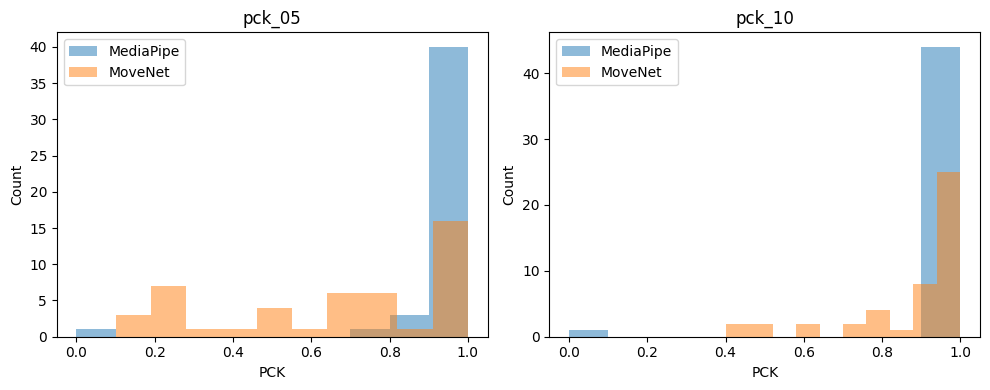

In [131]:
plt.figure(figsize=(10,4))

for i, metric in enumerate(["pck_05", "pck_10"]):
    plt.subplot(1, 2, i+1)
    for model_name, sub in df[df[metric].notna()].groupby("model"):
        plt.hist(sub[metric], bins=10, alpha=0.5, label=model_name)
    plt.title(metric)
    plt.xlabel("PCK")
    plt.ylabel("Count")
    plt.legend()

plt.tight_layout()
plt.show()


In [141]:
null_stats = (
    df.assign(is_null=df["pck_05"].isna())
      .groupby("model")["is_null"]
      .value_counts(normalize=True)
      .rename("share")
      .reset_index()
)

null_stats


,model,is_null,share
0,MediaPipe,False,0.681818
1,MediaPipe,True,0.318182
2,MoveNet,False,0.696970
3,MoveNet,True,0.303030


In [142]:
df_null = df[df["pck_05"].isna()].sort_values(["model", "image"])
df_null.head(20)


,model,image,time,pck_05,pck_10
3,MediaPipe,Tree_Pose (12).jpg,0.036553,NaN,NaN
5,MediaPipe,Tree_Pose (14).jpg,0.013953,NaN,NaN
11,MediaPipe,Tree_Pose (2).jpg,0.032522,NaN,NaN
12,MediaPipe,Tree_Pose (20).jpg,0.033951,NaN,NaN
14,MediaPipe,Tree_Pose (22).jpg,0.014950,NaN,NaN
27,MediaPipe,Tree_Pose (34).jpg,0.034885,NaN,NaN
32,MediaPipe,Tree_Pose (39).jpg,0.034883,NaN,NaN
36,MediaPipe,Tree_Pose (42).jpg,0.014950,NaN,NaN
37,MediaPipe,Tree_Pose (43).jpg,0.033887,NaN,NaN
42,MediaPipe,Tree_Pose (48).jpg,0.035811,NaN,NaN


In [143]:
import cv2 as cv
import numpy as np

def imread_unicode(path):
    with open(path, "rb") as f:
        data = f.read()
    img = cv.imdecode(np.frombuffer(data, np.uint8), cv.IMREAD_COLOR)
    return img


In [ ]:
import os

KEYPOINT_NAMES = [
    "nose",
    "left_eye",
    "right_eye",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_index", "right_index",
    "left_thumb", "right_thumb",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
    "left_heel", "right_heel",
    "left_foot_index", "right_foot_index"
]

def visualize_from_file(model_name, image_name, preds_by_model_image, gt):
    img_path = os.path.join(IMAGE_DIR, image_name)

    img = imread_unicode(img_path)

    if img is None:
        print("unable to load:", img_path)
        return

    h, w = img.shape[:2]

    if image_name not in gt:
        print("Нет GT для", image_name)
        return

    real = np.array([
        [np.nan, np.nan] if kp is None else kp
        for kp in gt[image_name]
    ], dtype=float)

    if model_name not in preds_by_model_image:
        print("no pred", model_name)
        return

    if image_name not in preds_by_model_image[model_name]:
        print("no pred", image_name)
        return

    pred = np.array(preds_by_model_image[model_name][image_name], dtype=float)

    vis = img.copy()

    for i, (x, y) in enumerate(real):
        if not np.isnan(x):
            cv.circle(vis, (int(x*w), int(y*h)), 5, (0,255,0), -1)
    
    cv.putText(vis, "TRUTH", (w-200, h-150), cv.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)


    for i, (x, y) in enumerate(pred):
        if not np.isnan(x):
            cv.circle(vis, (int(x*w), int(y*h)), 5, (0,0,255), -1)

    cv.putText(vis, "PREDICTED", (w-200, h-100), cv.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)

    plt.figure(figsize=(6,6))
    plt.imshow(cv.cvtColor(vis, cv.COLOR_BGR2RGB))
    plt.title(f"{model_name} - {image_name}")
    plt.legend()
    plt.axis("off")
    plt.show()


In [ ]:
best_mp = df[(df["model"]=="MediaPipe") & df["pck_05"].notna()].sort_values("pck_05", ascending=False).iloc[0]
best_mp


model              MediaPipe
image     Tree_Pose (11).jpg
time                 0.03887
pck_05                   1.0
pck_10                   1.0
Name: 2, dtype: object

C:\Users\Ульяна\AppData\Local\Temp\ipykernel_30416\477734779.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


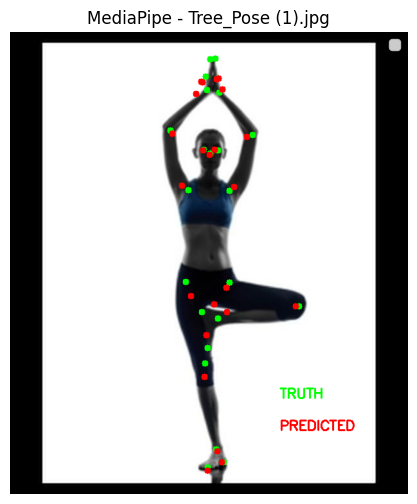

In [146]:
visualize_from_file(
    "MediaPipe",
    "Tree_Pose (1).jpg",
    preds_by_model_image,
    gt
)


C:\Users\Ульяна\AppData\Local\Temp\ipykernel_30416\477734779.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


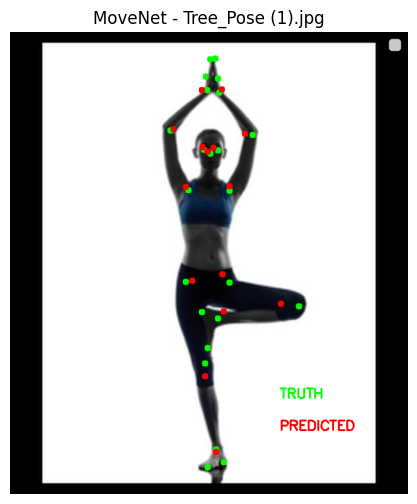

In [147]:
visualize_from_file(
    "MoveNet",
    "Tree_Pose (1).jpg",
    preds_by_model_image,
    gt
)


C:\Users\Ульяна\AppData\Local\Temp\ipykernel_30416\477734779.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


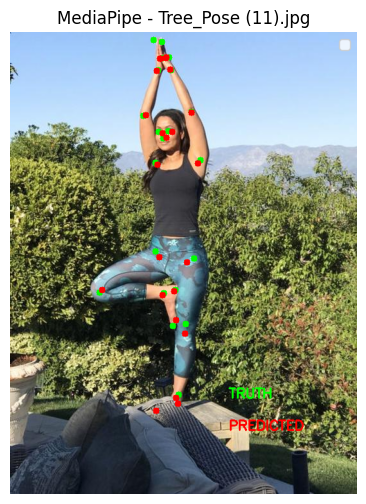

In [148]:
best = df[(df.model == "MediaPipe") & df.pck_05.notna()] \
          .sort_values("pck_05", ascending=False) \
          .iloc[0]

visualize_from_file(
    "MediaPipe",
    best.image,
    preds_by_model_image,
    gt
)


C:\Users\Ульяна\AppData\Local\Temp\ipykernel_30416\477734779.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


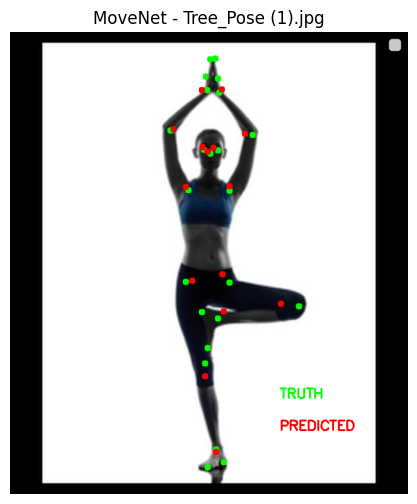

In [149]:
best = df[(df.model == "MoveNet") & df.pck_05.notna()] \
          .sort_values("pck_05", ascending=False) \
          .iloc[0]

visualize_from_file(
    "MoveNet",
    best.image,
    preds_by_model_image,
    gt
)


C:\Users\Ульяна\AppData\Local\Temp\ipykernel_30416\477734779.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


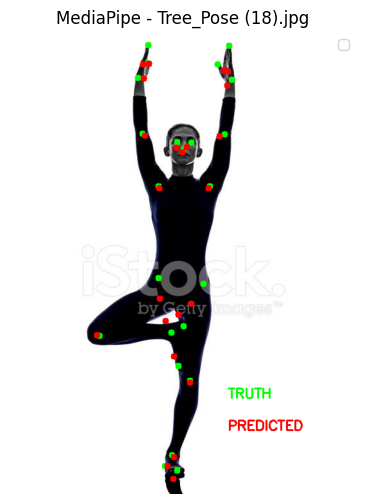

In [164]:
worst = df[(df.model == "MediaPipe") & df.pck_05.notna()] \
           .sort_values("pck_05") \
           .iloc[1]

visualize_from_file(
    "MediaPipe",
    worst.image,
    preds_by_model_image,
    gt
)


C:\Users\Ульяна\AppData\Local\Temp\ipykernel_30416\477734779.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


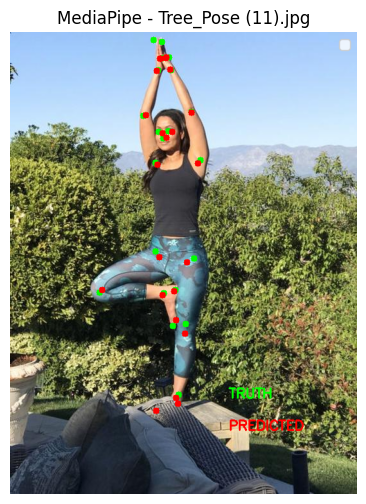

In [165]:
best = df[(df.model == "MediaPipe") & df.pck_05.notna()] \
          .sort_values("pck_05", ascending=False) \
          .iloc[0]

visualize_from_file(
    "MediaPipe",
    best.image,
    preds_by_model_image,
    gt
)


C:\Users\Ульяна\AppData\Local\Temp\ipykernel_30416\477734779.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


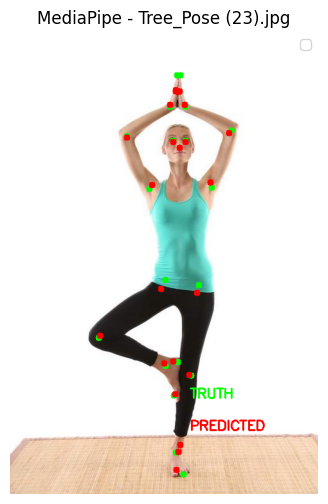

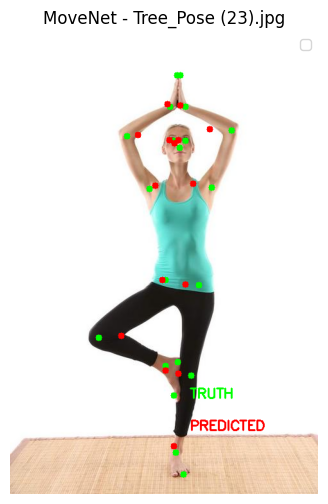

In [151]:
img = "Tree_Pose (23).jpg"

visualize_from_file("MediaPipe", img, preds_by_model_image, gt)
visualize_from_file("MoveNet", img, preds_by_model_image, gt)



In [158]:
def compute_errors(model_name, preds_by_model_image, gt):
    errors = []

    for image_name, real_kps in gt.items():
        if model_name not in preds_by_model_image:
            continue
        if image_name not in preds_by_model_image[model_name]:
            continue

        pred_kps = preds_by_model_image[model_name][image_name]

        if pred_kps is None or not isinstance(pred_kps, list) or len(pred_kps) == 0:
            continue

        pred_kps = np.array(pred_kps, dtype=float)
        real_kps = np.array([
            [np.nan, np.nan] if kp is None else kp
            for kp in real_kps
        ], dtype=float)

        L = min(len(real_kps), len(pred_kps))
        real_kps = real_kps[:L]
        pred_kps = pred_kps[:L]

        mask = ~np.isnan(real_kps[:,0]) & ~np.isnan(pred_kps[:,0])
        dist = np.full(L, np.nan)
        dist[mask] = np.linalg.norm(real_kps[mask] - pred_kps[mask], axis=1)

        errors.append(dist)

    return np.array(errors)



In [159]:

def plot_joint_error_distribution(errors, joint_names, model_name):
    mean_err = np.nanmean(errors, axis=0)
    median_err = np.nanmedian(errors, axis=0)

    plt.figure(figsize=(12,5))
    plt.bar(range(len(joint_names)), mean_err)
    plt.xticks(range(len(joint_names)), joint_names, rotation=90)
    plt.ylabel("AVG error (normalised)")
    plt.title(f"Error distribution by joints — {model_name}")
    plt.show()

    plt.figure(figsize=(12,5))
    plt.bar(range(len(joint_names)), median_err)
    plt.xticks(range(len(joint_names)), joint_names, rotation=90)
    plt.ylabel("Median error")
    plt.title(f"Median error by joints — {model_name}")
    plt.show()


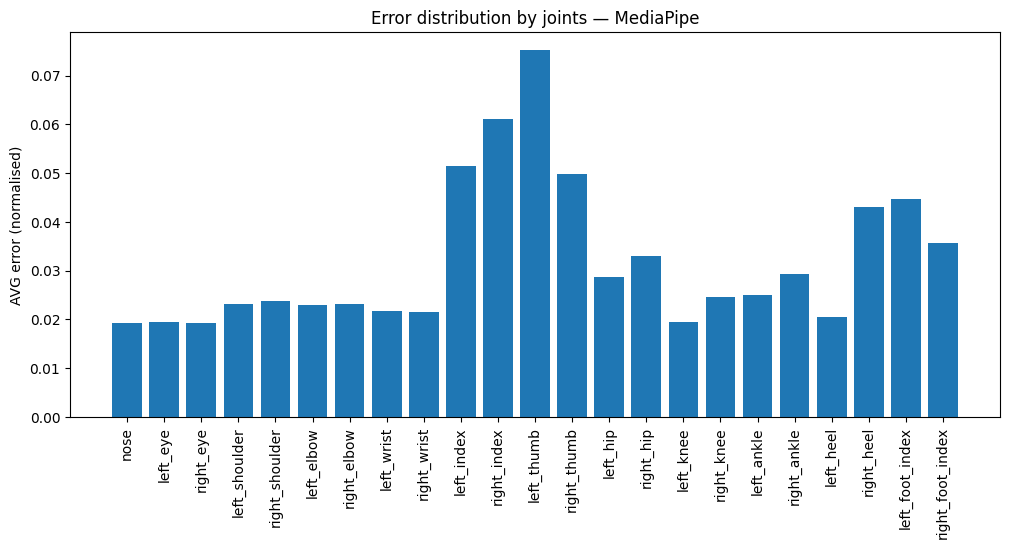

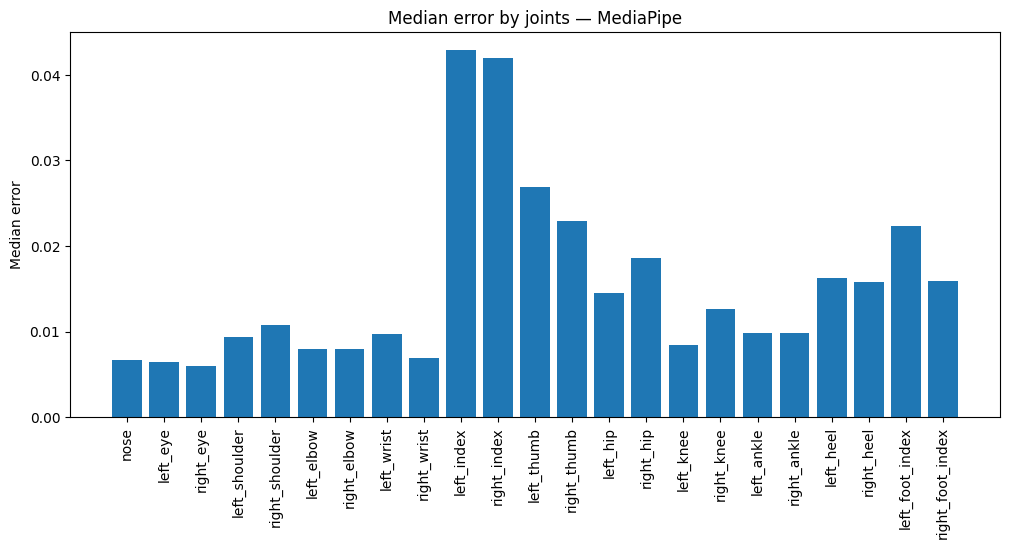

C:\Users\Ульяна\AppData\Local\Temp\ipykernel_30416\3961670852.py:2: RuntimeWarning: Mean of empty slice
  mean_err = np.nanmean(errors, axis=0)
C:\Users\Ульяна\AppData\Local\Temp\ipykernel_30416\3961670852.py:3: RuntimeWarning: All-NaN slice encountered
  median_err = np.nanmedian(errors, axis=0)


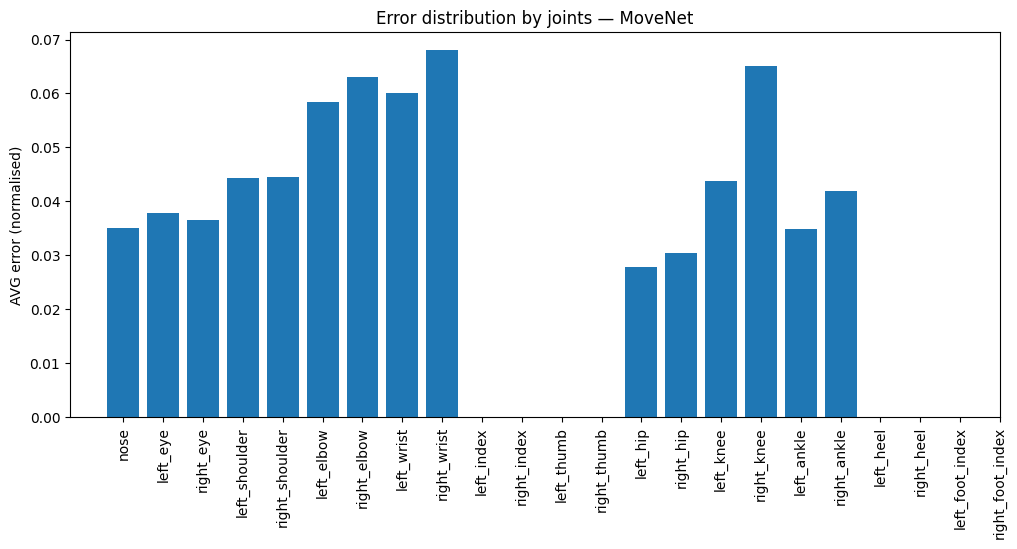

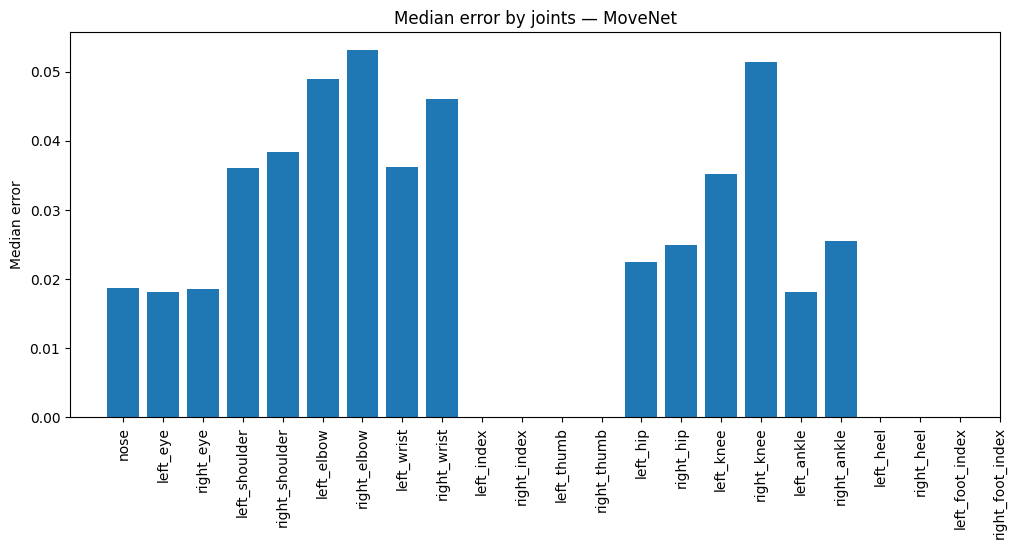

In [160]:
errors_mp = compute_errors("MediaPipe", preds_by_model_image, gt)
errors_mv = compute_errors("MoveNet", preds_by_model_image, gt)

plot_joint_error_distribution(errors_mp, KEYPOINT_NAMES, "MediaPipe")
plot_joint_error_distribution(errors_mv, KEYPOINT_NAMES, "MoveNet")


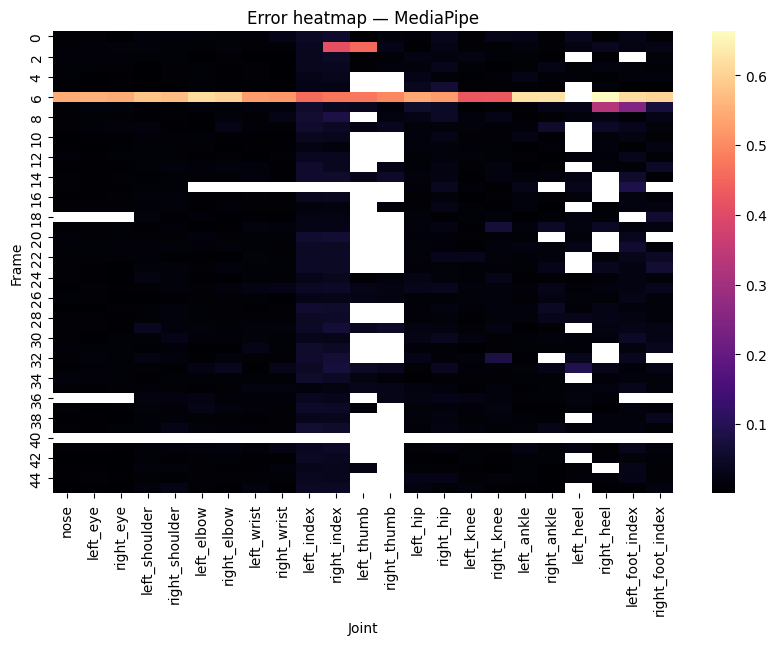

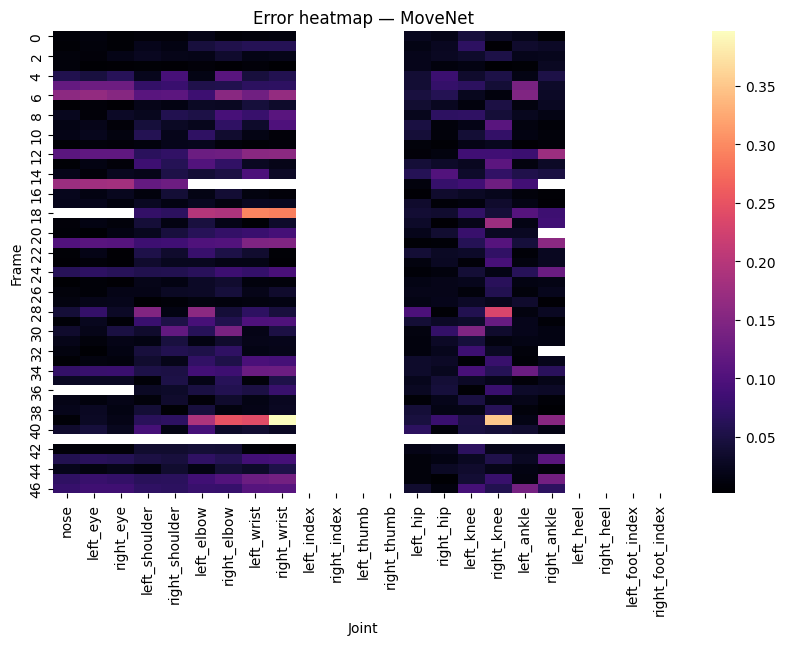

In [162]:
import seaborn as sns 

def plot_error_heatmap(errors, joint_names, model_name):
    plt.figure(figsize=(10,6))
    sns.heatmap(errors, cmap="magma", cbar=True)
    plt.xlabel("Joint")
    plt.ylabel("Frame")
    plt.title(f"Error heatmap — {model_name}")
    plt.xticks(np.arange(len(joint_names))+0.5, joint_names, rotation=90)
    plt.show()

plot_error_heatmap(errors_mp, KEYPOINT_NAMES, "MediaPipe")
plot_error_heatmap(errors_mv, KEYPOINT_NAMES, "MoveNet")
